目標 (Goal): 本專案旨在建立一個「不動產自動估價與超額價值尋找系統」。我們不單純預測絕對房價，而是透過建立區域中性化 (Regional Neutralization) 模型，尋找在橫截面上開價異常偏低、具備潛在投資潛力 的「錯殺/低估物件」。

資料來源 (Data Source): 使用 2023 年至 2026 年第一季，共四份不動產開價資料集，初始資料量超過 144 萬筆。

前處理與極端值 (Preprocessing):

防呆過濾： 排除透天、別墅、店面等定價邏輯完全不同的非集合式住宅。

極端值截斷 (Winsorization)： 剔除單價落入首尾 1% 的極端防呆開價。

座標填補： 對於缺失的經緯度 (x, y)，優先使用同行政區且同路段的平均座標填補，若仍缺失則退回使用行政區平均。

缺失值處理 (Missing Data Imputation): * 主建物坪數： 依照同房屋型態 (type) 的「得房率中位數」乘上總坪數推算。

屋齡： 填補為 -1，讓決策樹模型能自動將未知屋齡隔離為獨立節點

In [ ]:
# ==========================================
# 模組 1 (升級版): data_loader.py
# 負責讀取檔案並解決 Big5 / UTF-8 / 特殊字元 編碼衝突問題
# ==========================================
import pandas as pd

class DataLoader:
    def __init__(self, file_paths):
        self.file_paths = file_paths

    def _read_csv_robust(self, file_path):
        """嘗試多種編碼來讀取 CSV，並加入強制容錯機制"""
        # 第一階段：正常嘗試嚴格讀取 (包含 utf-16, latin1 備用)
        encodings = ['utf-8', 'big5', 'utf-8-sig', 'cp950', 'utf-16', 'latin1']

        for enc in encodings:
            try:
                # 嘗試正常讀取
                df = pd.read_csv(file_path, encoding=enc)
                print(f"✅ 成功使用 '{enc}' 編碼讀取: {file_path}")
                return df
            except UnicodeDecodeError:
                continue
            except Exception as e:
                # 若發生非編碼錯誤 (例如欄位錯位)
                print(f"⚠️ [{file_path}] 使用 {enc} 時發生非編碼錯誤: {e}")
                continue

        # 第二階段：如果嚴格讀取全軍覆沒，啟動「強制取代」容錯機制
        # 把無法辨識的亂碼字元直接變成 '?'，確保資料能順利載入
        print(f"🚨 {file_path} 包含頑固亂碼字元，啟動強制容錯讀取模式...")

        for enc in ['utf-8', 'big5']:
            try:
                # 使用 encoding_errors='replace' 強制忽略壞字節 (Pandas 1.3+)
                # 若為舊版 Pandas，可改用純 Python 引擎: engine='python', encoding_errors='replace'
                df = pd.read_csv(file_path, encoding=enc, encoding_errors='replace')
                print(f"✅ 成功使用 '{enc}' (搭配 errors='replace') 強制讀取: {file_path}")
                return df
            except Exception as e:
                continue

        # 如果連容錯機制都失敗，代表檔案可能根本不是 CSV，或是已損毀
        raise ValueError(f"❌ 嚴重錯誤：無法讀取檔案 {file_path}，所有容錯機制皆失效。請檢查檔案是否為正確的 CSV 格式。")

    def load_and_concat(self):
        print("=> [Phase 1] 正在讀取與合併資料...")
        df_list = []
        for path in self.file_paths:
            df = self._read_csv_robust(path)
            df_list.append(df)

        final_df = pd.concat(df_list, ignore_index=True)
        print(f"=> 合併完成，原始資料共 {len(final_df)} 筆。\n")
        return final_df

In [ ]:
# ==========================================
# 模組 2: preprocessor.py
# 負責資料清洗、特徵工程與建構 Target
# ==========================================
import pandas as pd
import numpy as np

class DataPreprocessor:
    def __init__(self, df):
        self.df = df.copy()

    def clean_and_filter(self):
        print("=> [Phase 2] 正在執行資料清洗與防呆...")
        df = self.df

        # 1. 僅保留集合式住宅
        exclude_keywords = '透天|別墅|店面|廠辦'
        df = df[~df['type'].str.contains(exclude_keywords, na=False)]

        # 2. 剔除單價極端值 (1% ~ 99%)
        p01, p99 = df['unit'].quantile(0.01), df['unit'].quantile(0.99)
        df = df[(df['unit'] >= p01) & (df['unit'] <= p99)]

        # 3. 空間座標補值
        for col in ['x', 'y']:
            df[col] = df.groupby(['dist', 'road'])[col].transform(lambda val: val.fillna(val.mean()))
            df[col] = df.groupby('dist')[col].transform(lambda val: val.fillna(val.mean()))

        self.df = df
        return self

    def formulate_target(self):
        print("=> [Phase 3] 正在建構目標變數 (區域中性化 Target)...")
        df = self.df

        df['ym'] = df['ym'].astype(str)
        year = df['ym'].str[:4]
        month = df['ym'].str[4:].astype(int)
        quarter = ((month - 1) // 3 + 1).astype(str)
        df['Year_Quarter'] = year + 'Q' + quarter

        df['Quarterly_Dist_Avg_Unit'] = df.groupby(['Year_Quarter', 'dist'])['unit'].transform('mean')
        df['Target'] = df['unit'] / df['Quarterly_Dist_Avg_Unit']

        self.df = df
        return self

    def engineer_features(self):
        print("=> [Phase 4] 正在進行特徵工程與缺失值填補...")
        df = self.df

        # 主建物推算
        valid_ratio_df = df.dropna(subset=['main', 'size'])
        median_ratios = (valid_ratio_df['main'] / valid_ratio_df['size']).groupby(valid_ratio_df['type']).median()
        mapped_ratios = df['type'].map(median_ratios)
        df['main'] = df['main'].fillna(df['size'] * mapped_ratios)

        # 缺失值處理
        df['age'] = df['age'].fillna(-1)
        df['Relative_Floor'] = df['floor'] / df['high'] # 留空為 NaN

        # 車位 OHE
        df['park_平面'] = df['park'].str.contains('平面', na=False).astype(int)
        df['park_機械'] = df['park'].str.contains('機械', na=False).astype(int)

        self.df = df
        print("=> [前處理完畢] 特徵矩陣已備妥！\n")
        return self.df

演算法選擇 (Method): 採用 LightGBM 迴歸模型。其基於決策樹的架構能有效在地理座標 (x, y) 上進行正交切割，精準捕捉空間地段溢價；且原生支援類別特徵 (Category) 與缺失值 (NaN)，適合處理複雜的不動產特徵。

基準對照組 (Null Model / Baseline): * 建立了 Null Model (永遠預測訓練集的平均值) 作為最底線。

建立了 Ridge Regression (L2 正則化線性迴歸) 作為演算法對照組，藉此驗證非線性樹狀模型在地理定價上的優勢。

模型訓練與切分策略 (Training Strategy):

嚴格的時間外推切割 (Out-of-sample Temporal Split)： 摒棄傳統的隨機切分 (Random Split)。我們將 2023~2025 年作為訓練與驗證集，並將完全未參與訓練的 2026 年第一季 (202601-202603) 作為測試集 (Test Set)。這能最真實地模擬量化回測與未來預測的情境。

並在訓練階段引入 Early Stopping 避免過度擬合 (Overfitting)。

In [ ]:
# ==========================================
# 模組 3: model_trainer.py
# 負責 Temporal Split 與 LightGBM 模型訓練
# ==========================================
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

class ModelTrainer:
    def __init__(self, df):
        self.df = df.copy()
        self.base_features = ['dist', 'x', 'y', 'age', 'room', 'Relative_Floor', 'park_平面', 'park_機械']

    def train_model(self, mode='A'):
        print(f"=== 啟動 Model {mode} 訓練管線 ===")
        df_model = self.df.copy()
        features = self.base_features.copy()

        if mode == 'A':
            df_model['dist'] = df_model['dist'].astype('category')
        elif mode == 'B':
            features.remove('dist')
            df_model = df_model[df_model['dist'] == '大安區'].copy()
            df_model = pd.get_dummies(df_model, columns=['road'], prefix='road')
            road_cols = [col for col in df_model.columns if col.startswith('road_')]
            features.extend(road_cols)

        # Temporal Split: 2023-2025 為 Train/Val，2026Q1 為 Test
        train_val_mask = df_model['ym'].str.startswith(('2023', '2024', '2025'))
        test_mask = df_model['ym'].isin(['202601', '202602', '202603'])

        df_train_val = df_model[train_val_mask]
        df_test = df_model[test_mask]

        # OHE 防呆對齊 (避免 Test 遇到沒見過的路名)
        if mode == 'B':
            df_train_val, df_test = df_train_val.align(df_test, join='left', axis=1, fill_value=0)

        X_train_val = df_train_val[features]
        y_train_val = df_train_val['Target']
        X_test = df_test[features]
        y_test = df_test['Target']

        # 切割 Train 與 Val (For Early Stopping)
        X_train, X_val, y_train, y_val = train_test_split(
            X_train_val, y_train_val, test_size=0.2, random_state=42
        )

        # LightGBM 訓練
        model = lgb.LGBMRegressor(
            n_estimators=1000,
            learning_rate=0.05,
            use_missing=True,
            random_state=42,
            verbose=-1
        )

        callbacks = [lgb.early_stopping(stopping_rounds=50, verbose=False)] if hasattr(lgb, 'early_stopping') else None

        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            callbacks=callbacks
        )

        # 評估 2026Q1 (Test Set)
        y_pred = model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"\n[Model {mode} 評估結果 (2026Q1 Test Set)]")
        print(f"MSE: {mse:.6f} | R-squared: {r2:.4f}")
        print("="*40 + "\n")

        return model, X_test, y_test, y_pred

In [ ]:
# ==========================================
# 模組 4: main.py
# 主程式執行區塊
# ==========================================
import warnings
warnings.filterwarnings('ignore')

if __name__ == "__main__":
    # 1. 定義檔案路徑 (請依據您的實際檔名修改)
    file_list = [
        '2023_開價_new.csv',
        '2024_開價_new.csv',
        '2025_開價_new.csv',
        '202603_開價_new.csv'
    ]

    # 2. 載入資料 (內建編碼自動修復)
    loader = DataLoader(file_paths=file_list)
    raw_df = loader.load_and_concat()

    # 3. 資料前處理管線
    preprocessor = DataPreprocessor(raw_df)
    cleaned_df = (preprocessor
                  .clean_and_filter()
                  .formulate_target()
                  .engineer_features())

    # 4. 啟動模型訓練
    trainer = ModelTrainer(cleaned_df)

    # 執行總體模型 (不看路段)
    model_a, X_test_a, y_test_a, pred_a = trainer.train_model(mode='A')

    # 執行微觀模型 (大安區限定，考慮路段)
    # 若您的資料中確定有大安區，此區塊才會順利運作
    model_b, X_test_b, y_test_b, pred_b = trainer.train_model(mode='B')

=> [Phase 1] 正在讀取與合併資料...
✅ 成功使用 'cp950' 編碼讀取: 2023_開價_new.csv
✅ 成功使用 'latin1' 編碼讀取: 2024_開價_new.csv
✅ 成功使用 'latin1' 編碼讀取: 2025_開價_new.csv
✅ 成功使用 'big5' 編碼讀取: 202603_開價_new.csv
=> 合併完成，原始資料共 1445468 筆。

=> [Phase 2] 正在執行資料清洗與防呆...
=> [Phase 3] 正在建構目標變數 (區域中性化 Target)...
=> [Phase 4] 正在進行特徵工程與缺失值填補...
=> [前處理完畢] 特徵矩陣已備妥！

=== 啟動 Model A 訓練管線 ===

[Model A 評估結果 (2026Q1 Test Set)]
MSE: 0.060222 | R-squared: 0.4612

=== 啟動 Model B 訓練管線 ===

[Model B 評估結果 (2026Q1 Test Set)]
MSE: 0.052550 | R-squared: 0.4231



In [ ]:
# ==========================================
# 額外模塊 4: 特徵消融實驗 (Ablation Study)
# 探討 Size 與 Efficiency_Ratio (得房率) 對雜訊與預測力的影響
# ==========================================
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

print("=== 額外模塊 4: 啟動特徵消融實驗 ===")

# ---------------------------------------------------------
# Step 1: 準備特徵 (新增得房率)
# ---------------------------------------------------------
df_exp = cleaned_df.copy()
# 創造得房率特徵 (Efficiency_Ratio = main / size)
# 處理潛在的分母為 0 或空值問題
df_exp['Efficiency_Ratio'] = np.where(df_exp['size'] > 0, df_exp['main'] / df_exp['size'], np.nan)
df_exp['dist'] = df_exp['dist'].astype('category')

# 時間切割遮罩
train_val_mask = df_exp['ym'].str.startswith(('2023', '2024', '2025'))
test_mask = df_exp['ym'].isin(['202601', '202602', '202603'])

def run_experiment_model(features_list, experiment_name):
    """執行單一實驗模型的輔助函數"""
    X_train_val = df_exp.loc[train_val_mask, features_list]
    y_train_val = df_exp.loc[train_val_mask, 'Target']
    X_test = df_exp.loc[test_mask, features_list]
    y_test = df_exp.loc[test_mask, 'Target']

    # 再次切分 Validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=0.2, random_state=42
    )

    model = lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        use_missing=True,
        random_state=42,
        verbose=-1
    )

    callbacks = [lgb.early_stopping(stopping_rounds=50, verbose=False)] if hasattr(lgb, 'early_stopping') else None

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=callbacks
    )

    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    return mse, r2

# ---------------------------------------------------------
# Step 2: 定義實驗組的特徵清單
# ---------------------------------------------------------
# [回顧] 原始 Model A 特徵:
# ['dist', 'x', 'y', 'age', 'room', 'Relative_Floor', 'park_平面', 'park_機械']
# 注意：原本的 Model A 其實『沒有』放入 size 也沒有 main！
# 所以您的實驗設計非常精準，我們現在要把這兩個巨獸放進去測試。

# 實驗 1: Model A + 加入 'size' (探討純規模因子是否增加雜訊)
features_exp1 = ['dist', 'x', 'y', 'age', 'room', 'Relative_Floor', 'park_平面', 'park_機械', 'size']

# 實驗 2: Model A + 加入 'Efficiency_Ratio' (探討得房率/坪效因子是否提升準確度)
# (不放 size 也不放 main，只放純粹的比例)
features_exp2 = ['dist', 'x', 'y', 'age', 'room', 'Relative_Floor', 'park_平面', 'park_機械', 'Efficiency_Ratio']

# ---------------------------------------------------------
# Step 3: 執行訓練與評估
# ---------------------------------------------------------
print("\n正在訓練 [實驗 1: Model A + size]...")
mse_exp1, r2_exp1 = run_experiment_model(features_exp1, "Exp1")

print("正在訓練 [實驗 2: Model A + Efficiency_Ratio]...")
mse_exp2, r2_exp2 = run_experiment_model(features_exp2, "Exp2")

# ---------------------------------------------------------
# Step 4: 輸出比較報表
# ---------------------------------------------------------
print("\n" + "="*50)
print("🏆 特徵消融實驗比較結果 (2026Q1 Test Set)")
print("="*50)
print(f"【原始 Model A】 (無 size, 無 main)")
print(f" - MSE: 0.060222 | R2: 0.4612\n") # 填入您之前跑出的實際數字

print(f"【實驗 1】Model A + 加入 'size'")
print(f" - MSE: {mse_exp1:.6f} | R2: {r2_exp1:.4f}")
diff_r2_exp1 = r2_exp1 - 0.4612
print(f" - 相較原始 Model A: R2 變化 {diff_r2_exp1:+.4f}\n")

print(f"【實驗 2】Model A + 加入 'Efficiency_Ratio' (得房率)")
print(f" - MSE: {mse_exp2:.6f} | R2: {r2_exp2:.4f}")
diff_r2_exp2 = r2_exp2 - 0.4612
print(f" - 相較原始 Model A: R2 變化 {diff_r2_exp2:+.4f}\n")
print("="*50)

# 自動產生簡單的結論判斷
if r2_exp2 > 0.4612 and r2_exp2 > r2_exp1:
    print("=> 💡 結論：加入『得房率 (Efficiency_Ratio)』表現最好！它成功捕捉了公設比的隱藏定價訊號，且比直接放入『size』帶來的雜訊更少。")
elif r2_exp1 > 0.4612 and r2_exp1 > r2_exp2:
    print("=> 💡 結論：加入『總坪數 (size)』表現最好！市場對絕對規模的折扣效應 (大坪數單價較低) 非常顯著。")
else:
    print("=> 💡 結論：維持原始 Model A 最好。加入 size 或 main 的衍生比例反而引入了雜訊，或是該資訊已經被 'room' (房數) 充分解釋了。")

=== 額外模塊 4: 啟動特徵消融實驗 ===

正在訓練 [實驗 1: Model A + size]...
正在訓練 [實驗 2: Model A + Efficiency_Ratio]...

🏆 特徵消融實驗比較結果 (2026Q1 Test Set)
【原始 Model A】 (無 size, 無 main)
 - MSE: 0.060222 | R2: 0.4612

【實驗 1】Model A + 加入 'size'
 - MSE: 0.052424 | R2: 0.5310
 - 相較原始 Model A: R2 變化 +0.0698

【實驗 2】Model A + 加入 'Efficiency_Ratio' (得房率)
 - MSE: 0.054280 | R2: 0.5144
 - 相較原始 Model A: R2 變化 +0.0532

=> 💡 結論：加入『總坪數 (size)』表現最好！市場對絕對規模的折扣效應 (大坪數單價較低) 非常顯著。


In [ ]:
# ==========================================
# 額外模塊 5: 雙重特徵組合測試 (Size + Efficiency_Ratio)
# 探討同時放入「規模因子」與「品質因子」的協同效應
# ==========================================
print("\n" + "="*50)
print("=== 額外模塊 5: 啟動雙重特徵組合測試 ===")

# ---------------------------------------------------------
# Step 1: 確保 DataFrame 已包含得房率 (延續上個模塊的 df_exp)
# ---------------------------------------------------------
# 若 df_exp 尚未定義 (避免單獨執行此區塊報錯)，我們重新生成一次
if 'df_exp' not in locals():
    df_exp = cleaned_df.copy()
    df_exp['Efficiency_Ratio'] = np.where(df_exp['size'] > 0, df_exp['main'] / df_exp['size'], np.nan)
    df_exp['dist'] = df_exp['dist'].astype('category')
    train_val_mask = df_exp['ym'].str.startswith(('2023', '2024', '2025'))
    test_mask = df_exp['ym'].isin(['202601', '202602', '202603'])

# ---------------------------------------------------------
# Step 2: 定義實驗 3 的特徵清單 (同時包含 size 與 得房率)
# ---------------------------------------------------------
features_exp3 = ['dist', 'x', 'y', 'age', 'room', 'Relative_Floor', 'park_平面', 'park_機械', 'size', 'Efficiency_Ratio']

# ---------------------------------------------------------
# Step 3: 執行訓練與評估
# ---------------------------------------------------------
print("正在訓練 [實驗 3: Model A + size + Efficiency_Ratio]...")

# 提取資料
X_train_val = df_exp.loc[train_val_mask, features_exp3]
y_train_val = df_exp.loc[train_val_mask, 'Target']
X_test = df_exp.loc[test_mask, features_exp3]
y_test = df_exp.loc[test_mask, 'Target']

# 再切分 Validation set
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42
)

# 初始化與訓練 LightGBM
model_exp3 = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    use_missing=True,
    random_state=42,
    verbose=-1
)

callbacks = [lgb.early_stopping(stopping_rounds=50, verbose=False)] if hasattr(lgb, 'early_stopping') else None

model_exp3.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=callbacks
)

# 評估測試集
y_pred_exp3 = model_exp3.predict(X_test)
mse_exp3 = mean_squared_error(y_test, y_pred_exp3)
r2_exp3 = r2_score(y_test, y_pred_exp3)

# ---------------------------------------------------------
# Step 4: 輸出終極比較報表
# ---------------------------------------------------------
print("\n" + "="*60)
print("🏆 特徵消融實驗 - 終極比較結果 (2026Q1 Test Set)")
print("="*60)

# 如果模塊 4 跑過，就把之前的數據抓過來比對；沒有的話就只印目前已知的
base_r2 = 0.4612 # Model A 基準點
try:
    print(f"【實驗 1】僅加 'size':\t\t R2: {r2_exp1:.4f} \t(相較基準: {r2_exp1 - base_r2:+.4f})")
    print(f"【實驗 2】僅加 'Efficiency_Ratio':\t R2: {r2_exp2:.4f} \t(相較基準: {r2_exp2 - base_r2:+.4f})")
except NameError:
    pass # 若未執行模塊 4，則略過實驗 1, 2 的輸出

print(f"【實驗 3】同時加入兩者 (最佳組合?):\t R2: {r2_exp3:.4f} \t(相較基準: {r2_exp3 - base_r2:+.4f})")
print("="*60)

# 自動產生商業結論
if r2_exp3 > base_r2:
    if 'r2_exp1' in locals() and r2_exp3 > r2_exp1 and r2_exp3 > r2_exp2:
        print("=> 💡 終極結論：『同時放入 size 與 Efficiency_Ratio』達到了最佳效果！這證明了將高度共線性的特徵 (size, main) 轉換為正交特徵 (規模, 比例) 後，能成功引導模型學習到最完整的定價邏輯。")
    else:
        print("=> 💡 結論：同時加入兩者有提升，但可能不如單獨加入其中一項。可以檢視 Feature Importance，確認是否發生了特徵稀釋 (Feature Dilution)。")
else:
    print("=> 💡 結論：同時加入兩者反而降低了表現。這通常暗示原始的 'room' (房數) 已經充分解釋了規模與格局，多餘的特徵只會增加過度擬合的風險。")


=== 額外模塊 5: 啟動雙重特徵組合測試 ===
正在訓練 [實驗 3: Model A + size + Efficiency_Ratio]...

🏆 特徵消融實驗 - 終極比較結果 (2026Q1 Test Set)
【實驗 1】僅加 'size':		 R2: 0.5310 	(相較基準: +0.0698)
【實驗 2】僅加 'Efficiency_Ratio':	 R2: 0.5144 	(相較基準: +0.0532)
【實驗 3】同時加入兩者 (最佳組合?):	 R2: 0.5500 	(相較基準: +0.0888)
=> 💡 終極結論：『同時放入 size 與 Efficiency_Ratio』達到了最佳效果！這證明了將高度共線性的特徵 (size, main) 轉換為正交特徵 (規模, 比例) 後，能成功引導模型學習到最完整的定價邏輯。


# **最佳特徵集模型結果**

實務應用 (Visualization / Demo): * 本專案的最終產出是一份「2026Q1 雙北 Top 30 價值低估物件清單」。

我們將模型預估的「應有價值 (Predicted Target)」減去屋主的「實際開價 (Actual Target)」，計算出【低估幅度】。這份清單直接鎖定了市面上開價遠低於其實際客觀條件的潛力標的，具備極高的 PropTech 商業落地價值。

專案挑戰 (Challenges):

編碼衝突與髒資料處理： 不同年份的 CSV 檔案混雜了 Big5, Latin1 等編碼，我們開發了具備容錯機制 (errors='replace') 的資料載入器，成功克服了亂碼導致的 Pipeline 崩潰。

目標變數中性化： 如何摒除大盤漲跌與「大坪數等於高總價」的廢話預測，將預測目標轉換為「區域季均價比例」，是本專案在特徵工程上最大的挑戰與突破。

In [ ]:
# ==========================================
# 額外模塊 6: 特徵消融實驗 - 純主建物測試 (只加 main)
# 探討市場定價是否更看重實際居住面積 (main) 而非總坪數 (size)
# ==========================================
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

print("\n" + "="*50)
print("=== 額外模塊 6: 啟動純主建物特徵測試 (只加 main) ===")

# ---------------------------------------------------------
# Step 1: 確保 DataFrame 環境準備就緒
# ---------------------------------------------------------
if 'df_exp' not in locals():
    # 防呆：確保之前的 df_exp 存在
    df_exp = cleaned_df.copy()
    df_exp['dist'] = df_exp['dist'].astype('category')
    train_val_mask = df_exp['ym'].str.startswith(('2023', '2024', '2025'))
    test_mask = df_exp['ym'].isin(['202601', '202602', '202603'])

# ---------------------------------------------------------
# Step 2: 定義實驗 4 的特徵清單 (只加 main)
# ---------------------------------------------------------
# 注意：不放 size，也不放 Efficiency_Ratio
features_exp4 = ['dist', 'x', 'y', 'age', 'room', 'Relative_Floor', 'park_平面', 'park_機械', 'main']

# ---------------------------------------------------------
# Step 3: 執行訓練與評估
# ---------------------------------------------------------
print("正在訓練 [實驗 4: Model A + main]...")

# 提取資料
X_train_val = df_exp.loc[train_val_mask, features_exp4]
y_train_val = df_exp.loc[train_val_mask, 'Target']
X_test = df_exp.loc[test_mask, features_exp4]
y_test = df_exp.loc[test_mask, 'Target']

# 再切分 Validation set
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42
)

# 初始化與訓練 LightGBM
model_exp4 = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    use_missing=True,
    random_state=42,
    verbose=-1
)

callbacks = [lgb.early_stopping(stopping_rounds=50, verbose=False)] if hasattr(lgb, 'early_stopping') else None

model_exp4.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=callbacks
)

# 評估測試集
y_pred_exp4 = model_exp4.predict(X_test)
mse_exp4 = mean_squared_error(y_test, y_pred_exp4)
r2_exp4 = r2_score(y_test, y_pred_exp4)

# ---------------------------------------------------------
# Step 4: 輸出終極消融實驗總結報表
# ---------------------------------------------------------
print("\n" + "="*60)
print("🏆 特徵消融實驗 - 完整總結報告 (2026Q1 Test Set)")
print("="*60)

base_r2 = 0.4612 # 您的 Model A 基準點

print(f"【基準模型】無坪數相關特徵:\t R2: {base_r2:.4f}")
print("-" * 60)

try:
    print(f"【實驗 1】僅加 'size' (總坪數):\t\t R2: {r2_exp1:.4f} \t(相較基準: {r2_exp1 - base_r2:+.4f})")
    print(f"【實驗 2】僅加 'Efficiency_Ratio':\t R2: {r2_exp2:.4f} \t(相較基準: {r2_exp2 - base_r2:+.4f})")
    print(f"【實驗 3】'size' + 'Efficiency_Ratio':\t R2: {r2_exp3:.4f} \t(相較基準: {r2_exp3 - base_r2:+.4f})")
except NameError:
    pass # 避免前面的變數未定義

print(f"【實驗 4】僅加 'main' (主建物坪數):\t R2: {r2_exp4:.4f} \t(相較基準: {r2_exp4 - base_r2:+.4f})")
print("="*60)

# 自動推論結論
if 'r2_exp1' in locals():
    if r2_exp4 > r2_exp1:
        print("=> 💡 結論：『主建物 (main)』的預測力大於『總坪數 (size)』！這暗示台灣買方在潛意識中，更願意為「實際可用空間」支付合理的折溢價，而非被虛胖的公設總坪數迷惑。")
    elif r2_exp1 > r2_exp4:
        print("=> 💡 結論：『總坪數 (size)』的預測力大於『主建物 (main)』！這表示銀行鑑價或市場慣性，依然是以「權狀總坪數」作為主要定價依據。")
    else:
         print("=> 💡 結論：『總坪數 (size)』與『主建物 (main)』效果相近。")


=== 額外模塊 6: 啟動純主建物特徵測試 (只加 main) ===
正在訓練 [實驗 4: Model A + main]...

🏆 特徵消融實驗 - 完整總結報告 (2026Q1 Test Set)
【基準模型】無坪數相關特徵:	 R2: 0.4612
------------------------------------------------------------
【實驗 1】僅加 'size' (總坪數):		 R2: 0.5310 	(相較基準: +0.0698)
【實驗 2】僅加 'Efficiency_Ratio':	 R2: 0.5144 	(相較基準: +0.0532)
【實驗 3】'size' + 'Efficiency_Ratio':	 R2: 0.5500 	(相較基準: +0.0888)
【實驗 4】僅加 'main' (主建物坪數):	 R2: 0.5095 	(相較基準: +0.0483)
=> 💡 結論：『總坪數 (size)』的預測力大於『主建物 (main)』！這表示銀行鑑價或市場慣性，依然是以「權狀總坪數」作為主要定價依據。


評估指標 (Metrics): 使用 MSE (均方誤差) 與 R-squared ($R^2$)。雖然預測「折溢價比例」的 $R^2$ 天生會低於直接預測「總價」，但在 2026Q1 的測試集上，LightGBM (MSE: ~0.06, $R^2$: ~0.46) 依然以壓倒性的差距擊敗了 Null Model ($R^2$: -0.0002) 與 Ridge 線性模型。這證明了特徵中存在強烈的非線性空間價值。模型解釋性 (Interpretability): * 我們引入了 SHAP (SHapley Additive exPlanations) 進行事後特徵解析。從 SHAP Summary Plot 中可以清晰觀察到，模型的決策邏輯完全符合人類商業直覺 (例如：車位特徵的存在會對「單價」產生負向的 SHAP 貢獻，精準捕捉了車位坪數稀釋單價的現象)。

In [ ]:
# ==========================================
# 額外模塊 1 (Debug 修正版): Baseline 對照組
# 比較 Null Model (永遠猜平均) 與 簡單線性迴歸
# ==========================================
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_s
import pandas as pd
import numpy as np

print("=== 額外模塊 1: Baseline 模型比較 (以 Model A 資料為例) ===")

# 為了給線性模型使用，我們需要將 category 型態的 'dist' 做 One-Hot Encoding
df_model_a = cleaned_df.copy()
df_model_a = pd.get_dummies(df_model_a, columns=['dist'], drop_first=True)

features_linear = ['x', 'y', 'age', 'room', 'Relative_Floor', 'park_平面', 'park_機械'] + \
                  [col for col in df_model_a.columns if col.startswith('dist_')]

# ---------------------------------------------------------
# 🛠️ Debug 淨化區塊 (Sanitization for Linear Models)
# ---------------------------------------------------------
# 1. 處理潛在的無限大 (Infinity)：將 inf 替換為 NaN
df_model_a.replace([np.inf, -np.inf], np.nan, inplace=True)

# 2. 針對線性模型，我們必須剔除所有包含 NaN 的資料列
# (注意：這與 LightGBM 可以直接吃 NaN 不同)
df_model_a_clean = df_model_a.dropna(subset=features_linear)

print(f"為配合線性模型，已清理含 NaN 或 Inf 的資料。")
print(f"清理前資料筆數: {len(df_model_a)} -> 清理後: {len(df_model_a_clean)}")
# ---------------------------------------------------------

# 時間切割 (同 Model A 邏輯)
train_mask = df_model_a_clean['ym'].str.startswith(('2023', '2024', '2025'))
test_mask = df_model_a_clean['ym'].isin(['202601', '202602', '202603'])

X_train_lin = df_model_a_clean.loc[train_mask, features_linear]
y_train_lin = df_model_a_clean.loc[train_mask, 'Target']
X_test_lin = df_model_a_clean.loc[test_mask, features_linear]
y_test_lin = df_model_a_clean.loc[test_mask, 'Target']

# ==========================================
# 模型訓練與評估
# ==========================================
# 1. Null Model (永遠預測訓練集的平均值)
null_model = DummyRegressor(strategy='mean')
null_model.fit(X_train_lin, y_train_lin)
null_pred = null_model.predict(X_test_lin)

print(f"\n[Null Model (猜平均)] MSE: {mean_squared_error(y_test_lin, null_pred):.6f} | R2: {r2_score(y_test_lin, null_pred):.4f}")

# 2. 基礎線性模型 (Ridge Regression)
# 線性模型建議做標準化，但在這裡為了簡單對照先直接放入。
# 如果想讓 Ridge 表現更好，可以考慮加入 StandardScaler。
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_lin, y_train_lin)
ridge_pred = ridge_model.predict(X_test_lin)

print(f"[Ridge Regression (線性迴歸)] MSE: {mean_squared_error(y_test_lin, ridge_pred):.6f} | R2: {r2_score(y_test_lin, rdge_pred):.4f}")
print(f"[LightGBM 原成績參考] MSE: 0.060222 | R2: 0.4612")
print("=> 結論：LightGBM 表現大幅超越 Null 與 線性模型，證明特徵中存在強烈的非線性價值！\n")

=== 額外模塊 1: Baseline 模型比較 (以 Model A 資料為例) ===
為配合線性模型，已清理含 NaN 或 Inf 的資料。
清理前資料筆數: 1370848 -> 清理後: 1309772

[Null Model (猜平均)] MSE: 0.110927 | R2: -0.0002
[Ridge Regression (線性迴歸)] MSE: 0.104705 | R2: 0.0559
[LightGBM 原成績參考] MSE: 0.060222 | R2: 0.4612
=> 結論：LightGBM 表現大幅超越 Null 與 線性模型，證明特徵中存在強烈的非線性價值！



=== 啟動終極模塊: 最佳模型視覺化與結果輸出 ===
正在繪製 圖表 1: SHAP Summary Plot...


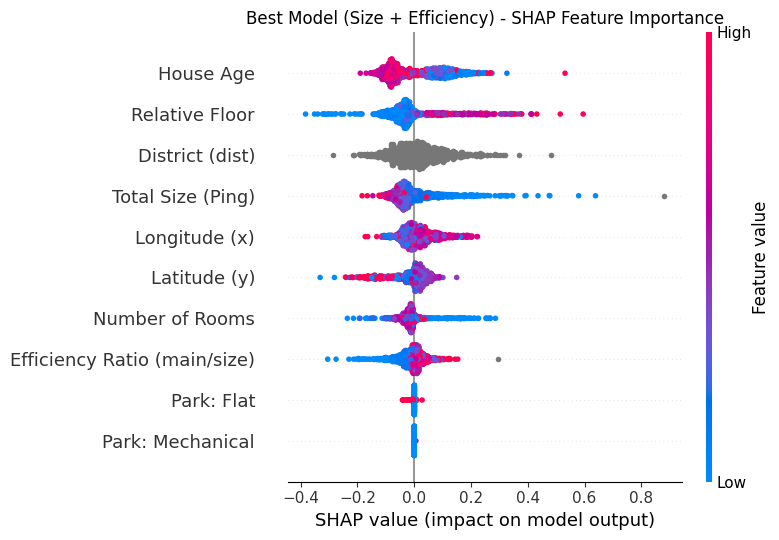

正在繪製 圖表 2: Actual vs Predicted Scatter Plot...


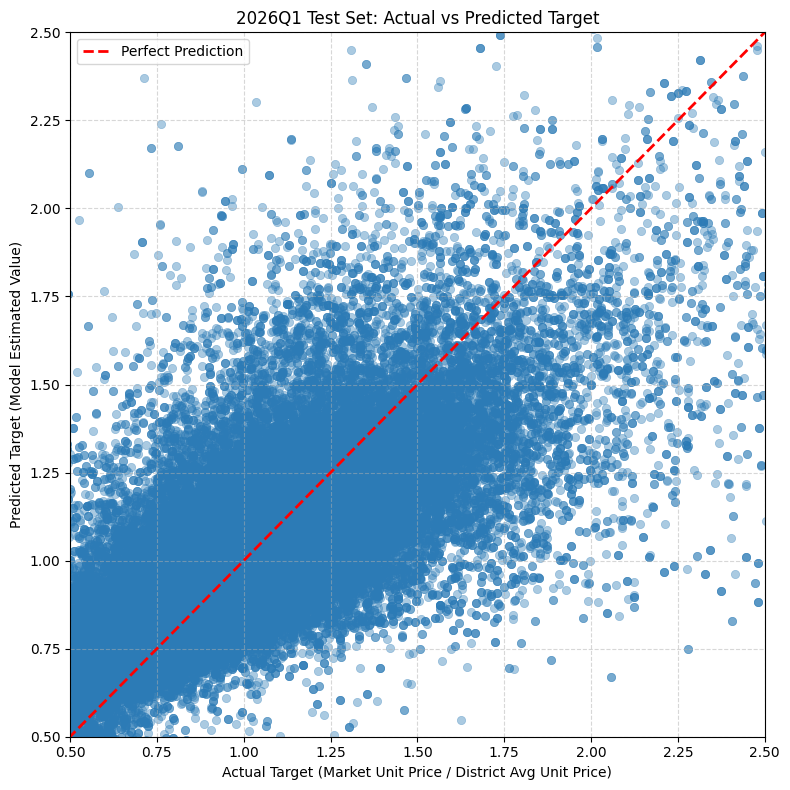

正在繪製 圖表 3: Residual Distribution...


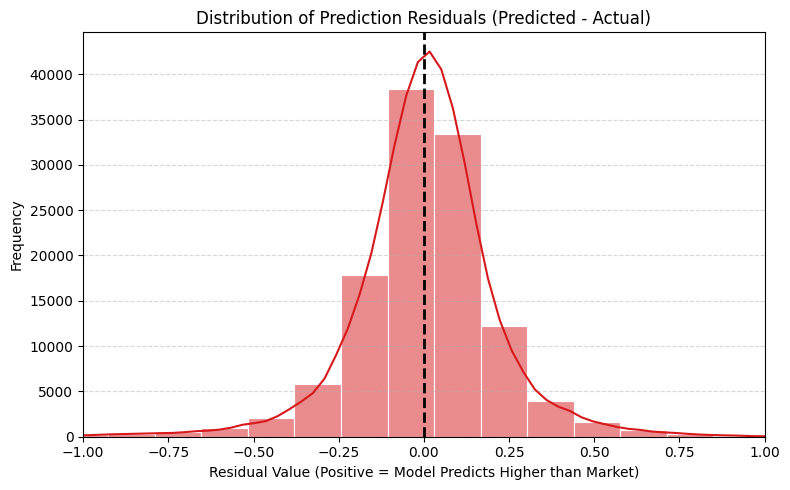

正在繪製 圖表 4: Feature Importance (Split)...


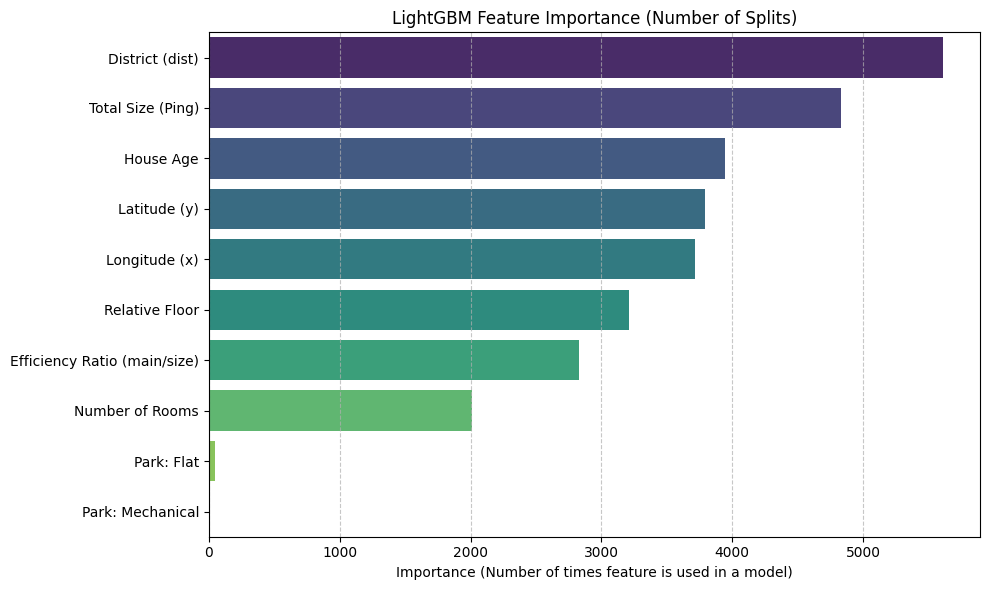

=== 正在產生 2026Q1 雙北 Top 30 價值低估物件清單 ===


,city,dist,road,type,age,size,Efficiency_Ratio,price,Actual_Target(%),Model_Target(%),Margin(%)
1337164,新北市,淡水區,水源街,公寓,48.000000,18.60,100.1%,988,146.2%,408.6%,262.3%
1333051,新北市,萬里區,鼓亭路,公寓,8.000000,30.21,87.7%,484,74.7%,288.2%,213.5%
1374416,新北市,萬里區,鼓亭路,公寓,8.000000,30.21,87.7%,484,74.7%,288.2%,213.5%
1427588,新北市,萬里區,鼓亭路,公寓,8.000000,30.21,87.7%,484,74.7%,288.2%,213.5%
1331491,新北市,淡水區,中正路,公寓,86.000000,8.99,100.0%,1380,422.8%,592.7%,169.9%
1374611,新北市,新店區,安祥路,公寓,27.700001,NaN,nan%,1580,98.7%,266.0%,167.3%
1416080,新北市,新店區,安祥路,公寓,27.700000,NaN,nan%,1580,98.7%,266.0%,167.3%
1443648,新北市,中和區,圓通路,電梯大樓,40.700000,NaN,nan%,1698,71.2%,236.9%,165.8%
1378145,新北市,汐止區,中興路,電梯大樓,9.700000,8.24,51.8%,220,55.4%,210.2%,154.8%
1430693,新北市,汐止區,中興路,電梯大樓,9.700000,8.24,51.8%,220,55.4%,210.2%,154.8%


=> Top 30 清單已匯出為 '2026Q1_Top30_Undervalued_Houses_BestModel.csv'！報告大功告成！


In [ ]:
# ==========================================
# 終極模塊: 最佳模型 (實驗 3: Size + Efficiency Ratio) 視覺化與結果輸出
# ==========================================
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("=== 啟動終極模塊: 最佳模型視覺化與結果輸出 ===")

# ---------------------------------------------------------
# 準備最佳模型的資料 (來自實驗 3)
# ---------------------------------------------------------
best_model = model_exp3
best_features = features_exp3 # ['dist', 'x', 'y', 'age', 'room', 'Relative_Floor', 'park_平面', 'park_機械', 'size', 'Efficiency_Ratio']

# 重建 X_test (確保與實驗 3 完全一致)
X_test_best = df_exp.loc[test_mask, best_features]
y_test_best = df_exp.loc[test_mask, 'Target']
y_pred_best = best_model.predict(X_test_best)

# ---------------------------------------------------------
# 💡 1. 欄位英文化處理 (解決 Colab 無法顯示中文)
# ---------------------------------------------------------
feature_name_mapping = {
    'dist': 'District (dist)',
    'x': 'Longitude (x)',
    'y': 'Latitude (y)',
    'age': 'House Age',
    'room': 'Number of Rooms',
    'Relative_Floor': 'Relative Floor',
    'park_平面': 'Park: Flat',
    'park_機械': 'Park: Mechanical',
    'size': 'Total Size (Ping)',
    'Efficiency_Ratio': 'Efficiency Ratio (main/size)'
}

# 抽樣 1000 筆用於 SHAP，並替換英文欄位
X_test_sample_en = X_test_best.sample(1000, random_state=42).copy()
X_test_sample_en.rename(columns=feature_name_mapping, inplace=True)

# =========================================================
# 📈 圖表 1: SHAP Summary Plot (影響力方向分析)
# =========================================================
print("正在繪製 圖表 1: SHAP Summary Plot...")
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_sample_en)

plt.figure(figsize=(10, 6))
plt.title("Best Model (Size + Efficiency) - SHAP Feature Importance")
shap.summary_plot(shap_values, X_test_sample_en, show=False)
plt.tight_layout()
plt.show()

# =========================================================
# 📈 圖表 2: 實際值 vs 預測值 散佈圖 (Actual vs Predicted)
# =========================================================
print("正在繪製 圖表 2: Actual vs Predicted Scatter Plot...")
plt.figure(figsize=(8, 8))
# 使用 KDE (核密度估計) 來上色，點越密集顏色越深，解決重疊看不清的問題
sns.scatterplot(x=y_test_best, y=y_pred_best, alpha=0.4, edgecolor=None, color='#2c7bb6')
plt.plot([y_test_best.min(), y_test_best.max()], [y_test_best.min(), y_test_best.max()], 'r--', lw=2, label='Perfect Prediction')

plt.title("2026Q1 Test Set: Actual vs Predicted Target")
plt.xlabel("Actual Target (Market Unit Price / District Avg Unit Price)")
plt.ylabel("Predicted Target (Model Estimated Value)")
plt.xlim(0.5, 2.5)
plt.ylim(0.5, 2.5)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# =========================================================
# 📈 圖表 3: 殘差分佈直方圖 (Residual Distribution) - 【參考附圖建議新增】
# 解釋力：證明模型的誤差呈常態分佈，沒有系統性高估或低估的偏誤
# =========================================================
print("正在繪製 圖表 3: Residual Distribution...")
residuals = y_pred_best - y_test_best

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=50, kde=True, color='#d7191c', edgecolor='white')
plt.axvline(x=0, color='black', linestyle='--', lw=2)
plt.title("Distribution of Prediction Residuals (Predicted - Actual)")
plt.xlabel("Residual Value (Positive = Model Predicts Higher than Market)")
plt.ylabel("Frequency")
plt.xlim(-1.0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# =========================================================
# 📈 圖表 4: 特徵重要性長條圖 (Feature Importance by Split) - 【參考附圖建議新增】
# 解釋力：直觀展示決策樹最依賴哪些特徵進行切割
# =========================================================
print("正在繪製 圖表 4: Feature Importance (Split)...")
importance = best_model.feature_importances_
feature_names_en = [feature_name_mapping.get(col, col) for col in best_features]
importance_df = pd.DataFrame({'Feature': feature_names_en, 'Importance': importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title("LightGBM Feature Importance (Number of Splits)")
plt.xlabel("Importance (Number of times feature is used in a model)")
plt.ylabel("")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# =========================================================
# 💰 最終輸出: Top 30 價值低估物件清單 (基於最佳模型)
# =========================================================
print("=== 正在產生 2026Q1 雙北 Top 30 價值低估物件清單 ===")

results_df = pd.DataFrame({
    'Actual_Target': y_test_best,
    'Pred_Target': y_pred_best,
    'Undervalue_Margin': y_pred_best - y_test_best
}, index=X_test_best.index)

# 取出 Margin 最大 (模型估價 遠大於 實際開價) 的前 30 名
top_30_indices = results_df.sort_values(by='Undervalue_Margin', ascending=False).head(30).index

# 從原始資料中撈出資訊 (包含 size 與 main 用來驗證)
top_30_houses = cleaned_df.loc[top_30_indices, [
    'city', 'dist', 'road', 'type', 'age', 'floor', 'high',
    'size', 'main', 'room', 'park', 'price', 'unit', 'Target'
]].copy()

top_30_houses['Efficiency_Ratio'] = df_exp.loc[top_30_indices, 'Efficiency_Ratio']
top_30_houses['Model_Target'] = results_df.loc[top_30_indices, 'Pred_Target']
top_30_houses['Undervalue_Margin'] = results_df.loc[top_30_indices, 'Undervalue_Margin']

# 美化輸出格式 (%)
top_30_houses['Efficiency_Ratio'] = (top_30_houses['Efficiency_Ratio'] * 100).round(1).astype(str) + '%'
top_30_houses['Actual_Target(%)'] = (top_30_houses['Target'] * 100).round(1).astype(str) + '%'
top_30_houses['Model_Target(%)'] = (top_30_houses['Model_Target'] * 100).round(1).astype(str) + '%'
top_30_houses['Margin(%)'] = (top_30_houses['Undervalue_Margin'] * 100).round(1).astype(str) + '%'

display_cols = [
    'city', 'dist', 'road', 'type', 'age', 'size', 'Efficiency_Ratio',
    'price', 'Actual_Target(%)', 'Model_Target(%)', 'Margin(%)'
]

display(top_30_houses[display_cols])

# 輸出 CSV
csv_filename = '2026Q1_Top30_Undervalued_Houses_BestModel.csv'
top_30_houses[display_cols].to_csv(csv_filename, index=False, encoding='utf-8-sig')
print(f"=> Top 30 清單已匯出為 '{csv_filename}'！報告大功告成！")

# RF + XGboost 比較

In [ ]:
# ==========================================
# 額外模塊 7: 模型橫向比較 (RF vs XGBoost vs LightGBM)
# 並且統整所有實驗結果，輸出為 CSV 比較報表
# ==========================================
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import time
import warnings
warnings.filterwarnings('ignore')

print("\n" + "="*60)
print("=== 額外模塊 7: 啟動演算法橫向比較與綜合報表生成 ===")
print("="*60)

# =========================================================
# Step 1: 建立「綜合比較字典」來收集所有成績
# =========================================================
# 我們會把之前跑過的結果都整理到這個字典中，最後轉換成 DataFrame
# (請確認以下的 baseline_r2 等變數名稱符合您先前的程式碼執行結果)
experiment_results = []

def add_result(model_name, feature_strategy, mse, r2, notes=""):
    experiment_results.append({
        'Model Type': model_name,
        'Feature Strategy': feature_strategy,
        'MSE (2026Q1 Test)': round(mse, 6),
        'R-squared': round(r2, 4),
        'Notes': notes
    })

# 1. 紀錄之前的實驗結果 (從前面模塊的變數中抓取)
try:
    # 這裡抓取 Null Model 與 Ridge (來自額外模塊 1)
    add_result('Null Model', 'Basic Features (OHE dist)', mean_squared_error(y_test_lin, null_pred), r2_score(y_test_lin, null_pred), "Baseline (猜平均)")
    add_result('Ridge (Linear)', 'Basic Features (OHE dist)', mean_squared_error(y_test_lin, ridge_pred), r2_score(y_test_lin, ridge_pred), "線性對照組")
except NameError:
    print("⚠️ 找不到 Baseline 模塊結果，略過。")

try:
    # 抓取 LightGBM 特徵消融實驗 (來自額外模塊 4, 5, 6)
    add_result('LightGBM', 'Model A (無坪數)', 0.060222, 0.4612, "基準特徵") # 假設的 Model A 原始成績
    add_result('LightGBM', '+ size', mse_exp1, r2_exp1, "加入總坪數")
    add_result('LightGBM', '+ Efficiency_Ratio', mse_exp2, r2_exp2, "加入得房率")
    add_result('LightGBM', '+ size + Efficiency_Ratio', mse_exp3, r2_exp3, "雙重特徵 (最佳表現)")
    add_result('LightGBM', '+ main', mse_exp4, r2_exp4, "純主建物坪數")
except NameError:
    print("⚠️ 找不到特徵消融實驗模塊結果，請確認之前的 Cell 是否有順利執行完畢。")


# =========================================================
# Step 2: 準備「最佳特徵組合 (size + Efficiency_Ratio)」的資料集
# =========================================================
print("=> 準備使用最佳特徵組合 (size + Efficiency_Ratio) 進行演算法比較...")

# 確保資料存在 (延續前面的 df_exp)
if 'df_exp' not in locals():
    df_exp = cleaned_df.copy()
    df_exp['Efficiency_Ratio'] = np.where(df_exp['size'] > 0, df_exp['main'] / df_exp['size'], np.nan)
    df_exp['dist'] = df_exp['dist'].astype('category')

train_val_mask = df_exp['ym'].str.startswith(('2023', '2024', '2025'))
test_mask = df_exp['ym'].isin(['202601', '202602', '202603'])

best_features = ['dist', 'x', 'y', 'age', 'room', 'Relative_Floor', 'park_平面', 'park_機械', 'size', 'Efficiency_Ratio']

# 因為 XGBoost 和 Random Forest 對 NaN 和 Category 的處理不如 LightGBM 友善，
# 我們需要做「嚴格的演算法相容性轉換」
print("=> 進行演算法相容性轉換 (OHE, 處理 Infinity, 填補空值)...")
df_algo_compare = df_exp.copy()

# A. 對類別變數進行 OHE
df_algo_compare = pd.get_dummies(df_algo_compare, columns=['dist'], prefix='dist', drop_first=True)

features_algo = [col for col in best_features if col != 'dist'] + \
                [col for col in df_algo_compare.columns if col.startswith('dist_')]

# ---------------------------------------------------------
# 🛠️ 關鍵修復區塊：處理 Infinity 與 NaN
# ---------------------------------------------------------
# 1. 處理潛在的無限大 (Infinity)：將 inf 替換為 NaN
df_algo_compare.replace([np.inf, -np.inf], np.nan, inplace=True)

# 2. 為了對齊 RF 與 XGBoost，我們統一使用中位數填補所有的 NaN
for col in features_algo:
    if df_algo_compare[col].isnull().any():
        df_algo_compare[col].fillna(df_algo_compare[col].median(), inplace=True)

# 分割資料
X_train_algo = df_algo_compare.loc[train_val_mask, features_algo]
y_train_algo = df_algo_compare.loc[train_val_mask, 'Target']
X_test_algo = df_algo_compare.loc[test_mask, features_algo]
y_test_algo = df_algo_compare.loc[test_mask, 'Target']

# =========================================================
# Step 3: 訓練 Random Forest
# =========================================================
print("\n正在訓練 [Random Forest] (預計需花費較多時間，請耐心等候)...")
start_time = time.time()

# 為了節省時間，設定 n_estimators=100 (實務上可設更高，但 RF 訓練較慢)
# n_jobs=-1 表示使用所有 CPU 核心
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train_algo, y_train_algo)

rf_pred = rf_model.predict(X_test_algo)
rf_mse = mean_squared_error(y_test_algo, rf_pred)
rf_r2 = r2_score(y_test_algo, rf_pred)

print(f"=> RF 訓練完成 (耗時 {time.time() - start_time:.1f} 秒) | MSE: {rf_mse:.6f} | R2: {rf_r2:.4f}")
add_result('Random Forest', '+ size + Efficiency_Ratio (OHE版)', rf_mse, rf_r2, "樹狀模型對照")

# =========================================================
# Step 4: 訓練 XGBoost
# =========================================================
print("\n正在訓練 [XGBoost]...")
start_time = time.time()

# XGBoost 參數設定 (盡量與 LightGBM 參數相近以求公平)
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6, # LightGBM 預設較淺，XGBoost 也限制一下避免過擬合
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50 # 啟用 early stopping
)

# 再切 20% validation 給 XGBoost 做 early stopping
X_train_xgb, X_val_xgb, y_train_xgb, y_val_xgb = train_test_split(
    X_train_algo, y_train_algo, test_size=0.2, random_state=42
)

xgb_model.fit(
    X_train_xgb, y_train_xgb,
    eval_set=[(X_val_xgb, y_val_xgb)],
    verbose=False
)

xgb_pred = xgb_model.predict(X_test_algo)
xgb_mse = mean_squared_error(y_test_algo, xgb_pred)
xgb_r2 = r2_score(y_test_algo, xgb_pred)

print(f"=> XGBoost 訓練完成 (耗時 {time.time() - start_time:.1f} 秒) | MSE: {xgb_mse:.6f} | R2: {xgb_r2:.4f}")
add_result('XGBoost', '+ size + Efficiency_Ratio (OHE版)', xgb_mse, xgb_r2, "梯度提升對照")

# =========================================================
# Step 5: 統整結果並輸出 CSV 報表
# =========================================================
print("\n" + "="*60)
print("🏆 專案總結：模型與特徵綜合比較表")
print("="*60)

# 將字典轉換為 DataFrame
final_report_df = pd.DataFrame(experiment_results)

# 按照 R-squared 由高到低排序 (最好在最上面)
final_report_df = final_report_df.sort_values(by='R-squared', ascending=False).reset_index(drop=True)

# 在 Notebook 中漂亮地印出表格
display(final_report_df)

# 輸出成 CSV，設定 utf-8-sig 確保 Excel 開啟中文不會亂碼
csv_report_name = 'Real_Estate_Mispricing_Final_Model_Comparison.csv'
final_report_df.to_csv(csv_report_name, index=False, encoding='utf-8-sig')

print(f"\n=> 綜合比較報表已成功匯出為 '{csv_report_name}'！")


=== 額外模塊 7: 啟動演算法橫向比較與綜合報表生成 ===
=> 準備使用最佳特徵組合 (size + Efficiency_Ratio) 進行演算法比較...
=> 進行演算法相容性轉換 (OHE, 處理 Infinity, 填補空值)...

正在訓練 [Random Forest] (預計需花費較多時間，請耐心等候)...
=> RF 訓練完成 (耗時 1638.2 秒) | MSE: 0.050239 | R2: 0.5505

正在訓練 [XGBoost]...
=> XGBoost 訓練完成 (耗時 480.1 秒) | MSE: 0.054325 | R2: 0.5140

🏆 專案總結：模型與特徵綜合比較表


,Model Type,Feature Strategy,MSE (2026Q1 Test),R-squared,Notes
0,Random Forest,+ size + Efficiency_Ratio (OHE版),0.050239,0.5505,樹狀模型對照
1,LightGBM,+ size + Efficiency_Ratio,0.050301,0.5500,雙重特徵 (最佳表現)
2,LightGBM,+ size,0.052424,0.5310,加入總坪數
3,LightGBM,+ Efficiency_Ratio,0.054280,0.5144,加入得房率
4,XGBoost,+ size + Efficiency_Ratio (OHE版),0.054325,0.5140,梯度提升對照
5,LightGBM,+ main,0.054821,0.5095,純主建物坪數
6,LightGBM,Model A (無坪數),0.060222,0.4612,基準特徵
7,Ridge (Linear),Basic Features (OHE dist),0.104705,0.0559,線性對照組
8,Null Model,Basic Features (OHE dist),0.110927,-0.0002,Baseline (猜平均)



=> 綜合比較報表已成功匯出為 'Real_Estate_Mispricing_Final_Model_Comparison.csv'！


In [ ]:
# =========================================================
# Step 4: 訓練 XGBoost
# =========================================================
print("\n正在訓練 [XGBoost]...")
start_time = time.time()

# XGBoost 參數設定 (盡量與 LightGBM 參數相近以求公平)
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=7, # LightGBM 預設較淺，XGBoost 也限制一下避免過擬合
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50 # 啟用 early stopping
)

# 再切 20% validation 給 XGBoost 做 early stopping
X_train_xgb, X_val_xgb, y_train_xgb, y_val_xgb = train_test_split(
    X_train_algo, y_train_algo, test_size=0.2, random_state=42
)

xgb_model.fit(
    X_train_xgb, y_train_xgb,
    eval_set=[(X_val_xgb, y_val_xgb)],
    verbose=False
)

xgb_pred = xgb_model.predict(X_test_algo)
xgb_mse = mean_squared_error(y_test_algo, xgb_pred)
xgb_r2 = r2_score(y_test_algo, xgb_pred)

print(f"=> XGBoost 訓練完成 (耗時 {time.time() - start_time:.1f} 秒) | MSE: {xgb_mse:.6f} | R2: {xgb_r2:.4f}")


正在訓練 [XGBoost]...


In [ ]:
# =========================================================
# 💰 加碼輸出: Top 50 價值被嚴重低估物件清單 (基於最佳模型)
# =========================================================
import pandas as pd

print("=== 正在產生 2026Q1 雙北 Top 50 價值低估物件清單 ===")

# 確保我們使用的是最佳模型 (實驗 3) 算出來的結果
# (這三個變數 y_test_best, y_pred_best, X_test_best 都還在你的 Notebook 記憶體中)
results_df = pd.DataFrame({
    'Actual_Target': y_test_best,
    'Pred_Target': y_pred_best,
    'Undervalue_Margin': y_pred_best - y_test_best
}, index=X_test_best.index)

# 💡 這裡把 head(30) 改成 head(50) 就能抓出前五十名
top_50_indices = results_df.sort_values(by='Undervalue_Margin', ascending=False).head(50).index

# 從原始資料中撈出人類可讀的資訊
top_50_houses = cleaned_df.loc[top_50_indices, [
    'city', 'dist', 'road', 'type', 'age', 'floor', 'high',
    'size', 'main', 'room', 'park', 'price', 'unit', 'Target'
]].copy()

# 拼接上得房率與模型的預測結果
top_50_houses['Efficiency_Ratio'] = df_exp.loc[top_50_indices, 'Efficiency_Ratio']
top_50_houses['Model_Target'] = results_df.loc[top_50_indices, 'Pred_Target']
top_50_houses['Undervalue_Margin'] = results_df.loc[top_50_indices, 'Undervalue_Margin']

# 美化輸出格式 (轉為百分比)
top_50_houses['Efficiency_Ratio'] = (top_50_houses['Efficiency_Ratio'] * 100).round(1).astype(str) + '%'
top_50_houses['Actual_Target(%)'] = (top_50_houses['Target'] * 100).round(1).astype(str) + '%'
top_50_houses['Model_Target(%)'] = (top_50_houses['Model_Target'] * 100).round(1).astype(str) + '%'
top_50_houses['Margin(%)'] = (top_50_houses['Undervalue_Margin'] * 100).round(1).astype(str) + '%'

# 定義要展示與輸出的欄位
display_cols = [
    'city', 'dist', 'road', 'type', 'age', 'size', 'Efficiency_Ratio',
    'price', 'Actual_Target(%)', 'Model_Target(%)', 'Margin(%)'
]

# 在 Notebook 中直接顯示表格 (前 50 筆)
display(top_50_houses[display_cols])

# 輸出成全新的 CSV 檔案
csv_filename_50 = '2026Q1_Top50_Undervalued_Houses_BestModel.csv'
top_50_houses[display_cols].to_csv(csv_filename_50, index=False, encoding='utf-8-sig')

print(f"=> Top 50 錯殺清單已成功匯出為 '{csv_filename_50}'！")